---
title: "PGC v1.1 data preprocessing"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-06"
file-modified: "2026-06-06"
abstract: "This notebook prepares the versioned PGC input files used by the Clorinn v2 pipeline. v1.1 removes biomarker traits, v1.2 additionally removes neurite density traits."
---

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor='black', dpi=300, colors='kelly')
from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Configuration and input files

The input files are taken from v1.0. 
[Click here to view the v1.0 data processing notebook](./2026-04-30-data-preprocessing-v1-0.ipynb).

The output files are versioned using `outsuffix = "v1_1" / "v1_2"` and written to `pgc_v1.1/` and `pgc_v1.2/`.

In [2]:
datadir = "/gpfs/commons/groups/knowles_lab/data/PsychGen/input"
inputdir    = Path(datadir) / "pgc_v1.0"
inputsuffix = "v1_0"
outdir      = Path(datadir) / "pgc_v1.2"
outsuffix   = "v1_2"

# Input files
zscore_file    = Path(inputdir) / f"zscore_{inputsuffix}.csv"
noise_cov_file = Path(inputdir) / f"sampling_covariance_{inputsuffix}.csv"
category_file  = Path(inputdir) / f"trait_to_group_{inputsuffix}.json"

# Output files
def ensure_parent(path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)

zscore_outfile    = Path(outdir) / f"zscore_{outsuffix}.csv"
noise_cov_outfile = Path(outdir) / f"sampling_covariance_{outsuffix}.csv"
category_outfile  = Path(outdir) / f"trait_to_group_{outsuffix}.json"
ensure_parent(zscore_outfile)
ensure_parent(noise_cov_outfile)
ensure_parent(category_outfile)

# Read files
def load_zscore(zscore_path):
    df = pd.read_csv(Path(zscore_path), header=0, index_col=0, dtype={0: str})
    df.index = df.index.map(str)
    df.columns = df.columns.map(str)
    return df

Z_df = load_zscore(zscore_file)
A_df = pd.read_csv(noise_cov_file, header = 0, index_col=0)
with open(category_file, "r") as f:
    trait_to_group = json.load(f)

## Look at the sampling covariance matrix

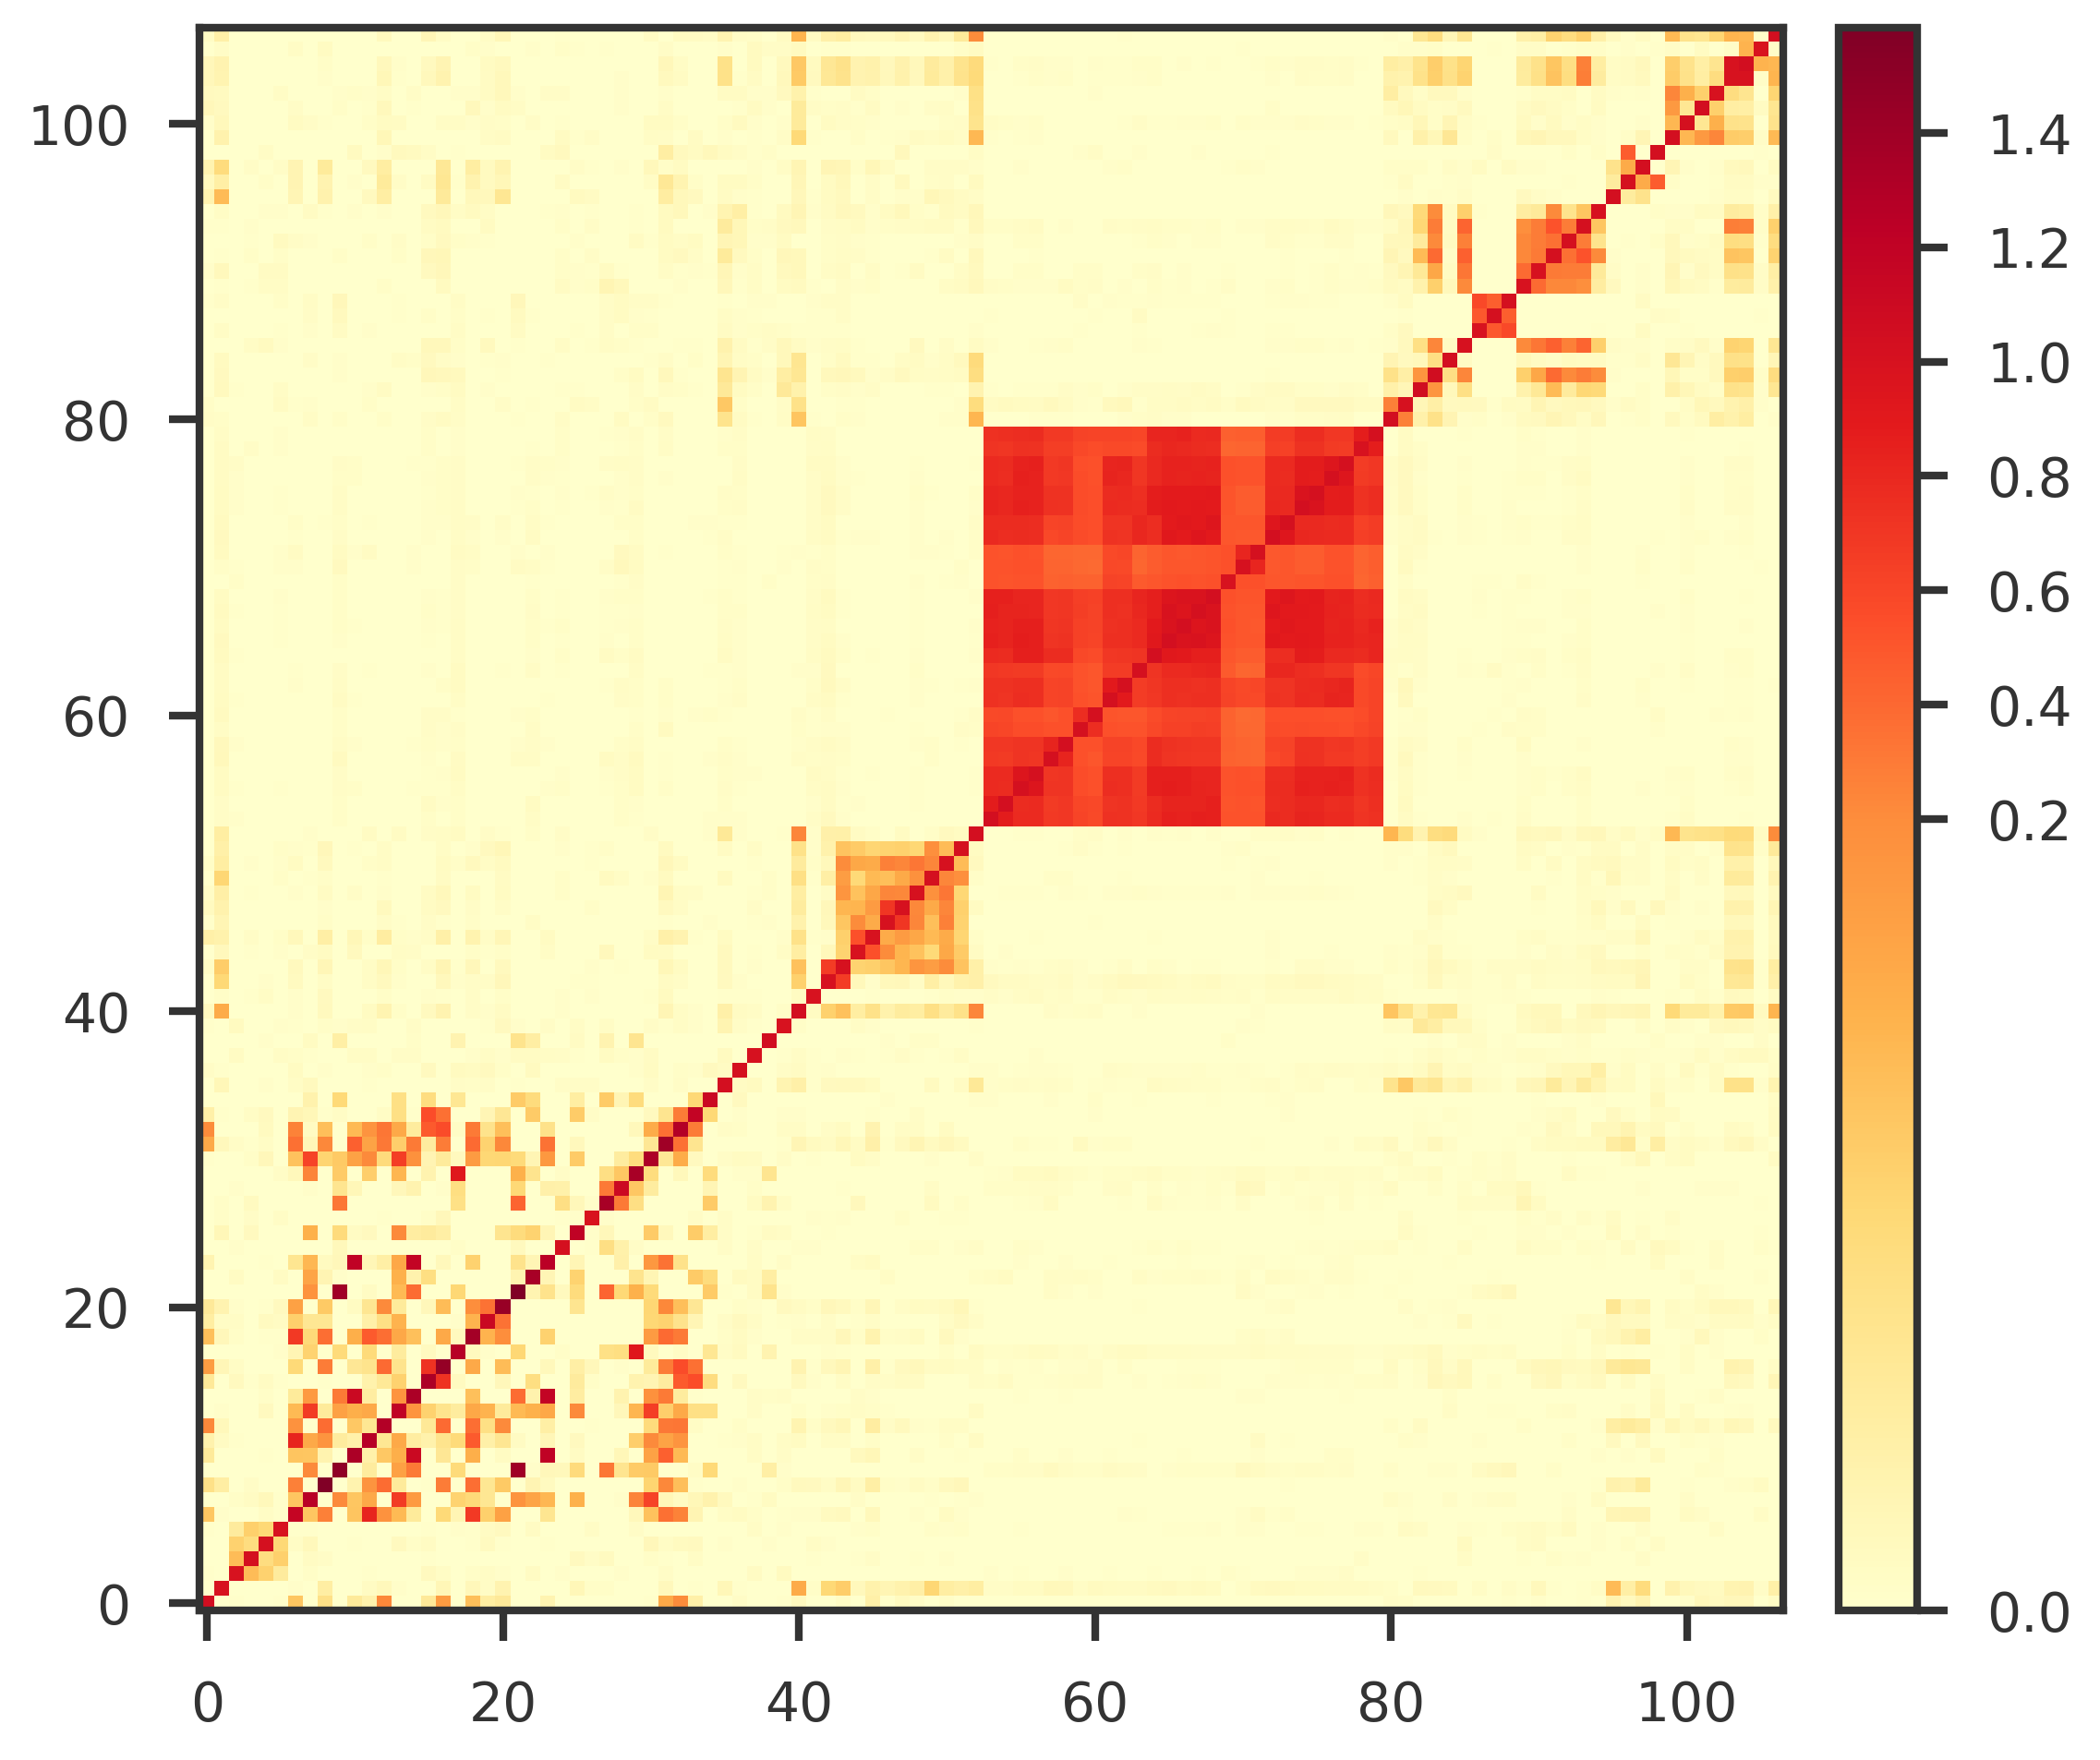

In [3]:
trait_names = list(Z_df.index)
sorted_trait_names = sorted(
    trait_names,
    key=lambda trait: trait_to_group[trait]
)

A_sorted = A_df.loc[sorted_trait_names, sorted_trait_names]
A = A_sorted.to_numpy()

fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111)

cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()
# norm1 = mpl_colors.TwoSlopeNorm(vcenter=np.mean(A))
norm1 = mpl_colors.TwoSlopeNorm(vmin=0, vcenter=0.2)

im1 = ax1.imshow(A, cmap=cmap1, norm=norm1, origin='lower')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.2)
cbar = plt.colorbar(im1, cax=cax, fraction=0.1)


plt.show()

In [4]:
np.unique(list(trait_to_group.values()))

array(['BMI', 'Big 5', 'Biomarker', 'Compulsive',
       'Educational attainment', 'Internalizing', 'Neurite density',
       'Neurodevelopmental', 'SCZ/BD/BPD', 'Sleep', 'Substance use',
       'Suicidality'], dtype='<U22')

## Remove groups of traits

In [5]:
groups_to_drop = [ "Biomarker" ,"Neurite density"]
keep_traits = [
    trait for trait in Z_df.index
    if trait_to_group[trait] not in groups_to_drop
]
Z_df = Z_df.loc[keep_traits]

In [6]:
Z_df.shape

(51, 46504)

## Remove redundant SNPs

- remove SNPs with missing values in at least 15 rows (20% of 78 total remaining rows).
- remove SNPs without significant z-score in at least 2 rows.

In [7]:
z_thresh = 1.96 # two-sided p < 0.05

keep_cols = (
    (Z_df.isna().sum(axis=0) < 15) &
    ((Z_df.abs() > z_thresh).sum(axis=0) >= 2)
)

Z_df = Z_df.loc[:, keep_cols]

In [8]:
Z_df.shape

(51, 38281)

## Align Z-scores and sampling covariance

After dropping unavailable traits, we take the common trait set and reorder both objects consistently.

The final aligned objects are:

- `Z_aligned`: traits × SNPs Z-score matrix;
- `A_aligned`: traits × traits sampling covariance matrix.

These are the objects written to disk for downstream Clorinn analyses.

In [9]:
common = A_df.index.intersection(A_df.index).intersection(Z_df.index)

# reorder consistently
A_aligned = A_df.loc[common, common]
Z_aligned = Z_df.loc[common, :]

# convert to numpy
A = A_aligned.to_numpy()
Z = Z_aligned.to_numpy()

print (f"Number of common traits: {len(common)}")
print (f"Number of SNPs: {Z.shape[1]}")

Number of common traits: 51
Number of SNPs: 38281


## Validate sampling covariance

The LDSC sampling covariance must be numerically well behaved for the correlated-noise Clorinn objective.

We check for symmetry and positive definiteness.

A symmetric positive-definite covariance is required for stable likelihood evaluation, inversion, and missingness-pattern-specific covariance operations downstream.

In [10]:
tol = 1e-8
is_symmetric = np.allclose(A, A.T, atol=tol, rtol=0)
if is_symmetric:
    print("This matrix is symmetric.")
else:
    print("This matrix is not symmetric.")
    max_asymmetry = np.abs(A - A.T).max()
    print("max_asymmetry:", max_asymmetry)

eigvals = np.linalg.eigvalsh((A + A.T) / 2)
is_pd = np.all(eigvals > 0)

if is_pd:
    print ("This matrix is PD.")
else:
    print ("This matrix is not PD.")
    print (f"Minimum eigenvalue: {eigvals.min():g}")
    print ("Zero / Negative eigenvalues:")
    print(eigvals[eigvals <= 0])


This matrix is symmetric.
This matrix is PD.


## Write release files

The final release files are:

| Object | Output file |
|:--|:--|
| aligned Z-score matrix | `zscore_v1_1.csv` / `... v1_2.csv` |
| aligned sampling covariance | `sampling_covariance_v1_1.csv` / `... v1_2.csv` |
| normalized trait-category map | `trait_to_group_v1_1.json` / `... v1_2.csv` |

These files define the PGC v1.1 / v1.2 input bundle used by the downstream Snakemake/Clorinn pipeline.

In [12]:
Z_aligned.to_csv(zscore_outfile)
A_aligned.to_csv(noise_cov_outfile)

with open(category_outfile, "w") as f:
    json.dump(trait_to_group, f, indent=4, sort_keys=True)